# Chennai Healthcare Access Analyzer 🏥🗺️

**Author:** Iniya
**Goal:** Identify underserved healthcare zones in Chennai using spatial analysis and K-Means clustering.
**Dataset:** 50 Chennai hospitals with location, type, bed count and emergency availability.

## Problem Statement
Which areas of Chennai lack adequate hospital access?
Government and city planners need data-driven insights to decide **where** to build new hospitals.
This project answers that question visually using geographic data and machine learning.


In [8]:
!pip install folium -q
import pandas as pd
import numpy as np
import folium
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from io import StringIO

print("All libraries loaded ✅")

All libraries loaded ✅


In [15]:
data = """name,type,area,latitude,longitude,beds,doctors,emergency
Rajiv Gandhi Government General Hospital,Government,Park Town,13.0827,80.2707,2500,800,Yes
Stanley Medical College Hospital,Government,Stanley,13.1127,80.2897,1531,600,Yes
Kilpauk Medical College Hospital,Government,Kilpauk,13.0900,80.2510,1172,450,Yes
Institute of Child Health,Government,Egmore,13.0732,80.2609,550,200,Yes
Government Royapettah Hospital,Government,Royapettah,13.0521,80.2660,500,180,Yes
ESI Hospital Ashok Nagar,ESI,Ashok Nagar,13.0316,80.2212,300,120,Yes
ESI Hospital KK Nagar,ESI,KK Nagar,13.0418,80.2040,250,100,Yes
ESI Hospital Ayanavaram,ESI,Ayanavaram,13.1043,80.2480,200,80,Yes
Apollo Hospitals Greams Road,Private,Greams Road,13.0569,80.2520,700,350,Yes
Fortis Malar Hospital,Private,Adyar,13.0012,80.2565,180,150,Yes
MIOT International,Private,Manapakkam,13.0156,80.1837,1000,400,Yes
Gleneagles Global Hospital,Private,Perumbakkam,12.9271,80.2133,1000,380,Yes
Sri Ramachandra Medical Centre,Private,Porur,13.0358,80.1586,700,300,Yes
Vijaya Hospital,Private,Vadapalani,13.0514,80.2121,350,140,Yes
Government Hospital Tambaram,Government,Tambaram,12.9249,80.1000,400,150,Yes
Government Hospital Chromepet,Government,Chromepet,12.9516,80.1418,200,80,No
Government Hospital Ambattur,Government,Ambattur,13.1143,80.1548,250,90,No
Government Hospital Tiruvottiyur,Government,Tiruvottiyur,13.1628,80.3040,200,75,No
Government Hospital Sholinganallur,Government,Sholinganallur,12.9010,80.2279,150,60,No
Government Hospital Anna Nagar,Government,Anna Nagar,13.0878,80.2101,300,110,Yes
Government Hospital Tondiarpet,Government,Tondiarpet,13.1200,80.2950,180,70,No
Government Hospital Madhavaram,Government,Madhavaram,13.1483,80.2310,150,55,No
Government Hospital Manali,Government,Manali,13.1671,80.2630,120,45,No
Government Hospital Poonamallee,Government,Poonamallee,13.0465,80.1165,200,75,No
Government Hospital Pallavaram,Government,Pallavaram,12.9675,80.1493,180,65,No
ESI Hospital Mylapore,ESI,Mylapore,13.0368,80.2676,150,60,No
ESI Hospital Perambur,ESI,Perambur,13.1200,80.2450,175,70,No
Apollo Hospitals OMR,Private,Perungudi,12.9550,80.2410,200,100,Yes
Fortis Hospital Vadapalani,Private,Vadapalani,13.0530,80.2090,250,110,Yes
Government Hospital Guindy,Government,Guindy,13.0067,80.2206,350,130,Yes
Government Hospital Velachery,Government,Velachery,12.9815,80.2209,200,80,No
Government Hospital Adyar,Government,Adyar,13.0012,80.2565,180,70,No
Government Hospital Mylapore,Government,Mylapore,13.0395,80.2680,220,85,No
Government Hospital Nungambakkam,Government,Nungambakkam,13.0569,80.2412,190,75,No
Government Hospital Perungudi,Government,Perungudi,12.9610,80.2440,160,60,No
Government Hospital Kolathur,Government,Kolathur,13.1214,80.2214,170,65,No
Government Hospital Villivakkam,Government,Villivakkam,13.1028,80.2140,160,62,No
Government Hospital Nerkundram,Government,Nerkundram,13.0678,80.1890,140,55,No
Government Hospital Mugalivakkam,Government,Mugalivakkam,13.0198,80.1698,130,50,No
Government Hospital Gerugambakkam,Government,Gerugambakkam,12.9987,80.1548,120,45,No
Government Hospital Medavakkam,Government,Medavakkam,12.9198,80.2010,150,58,No
Government Hospital Selaiyur,Government,Selaiyur,12.9098,80.1498,130,50,No
Government Hospital Hasthinapuram,Government,Hasthinapuram,12.9198,80.1598,140,54,No
Government Hospital Nanmangalam,Government,Nanmangalam,12.9698,80.1798,120,46,No
Government Hospital Kovilambakkam,Government,Kovilambakkam,12.9398,80.1998,130,50,No
Kauvery Hospital Alwarpet,Private,Alwarpet,13.0358,80.2529,350,160,Yes
Kauvery Hospital Vadapalani,Private,Vadapalani,13.0521,80.2100,300,130,Yes
Sundaram Medical Foundation,Private,Anna Nagar,13.0850,80.2101,200,100,Yes
Government Hospital Kolathur,Government,Kolathur,13.1214,80.2214,170,65,No
Government Hospital Perambur,Government,Perambur,13.1150,80.2430,190,72,No"""

df = pd.read_csv(StringIO(data))
print("Dataset loaded ✅")
print("Shape:", df.shape)
print(df.head())

Dataset loaded ✅
Shape: (50, 8)
                                       name        type        area  latitude  \
0  Rajiv Gandhi Government General Hospital  Government   Park Town   13.0827   
1          Stanley Medical College Hospital  Government     Stanley   13.1127   
2          Kilpauk Medical College Hospital  Government     Kilpauk   13.0900   
3                 Institute of Child Health  Government      Egmore   13.0732   
4            Government Royapettah Hospital  Government  Royapettah   13.0521   

   longitude  beds  doctors emergency  
0    80.2707  2500      800       Yes  
1    80.2897  1531      600       Yes  
2    80.2510  1172      450       Yes  
3    80.2609   550      200       Yes  
4    80.2660   500      180       Yes  


HOSPITAL TYPE DISTRIBUTION
type
Government    34
Private       11
ESI            5
Name: count, dtype: int64

AVERAGE BEDS BY HOSPITAL TYPE
type
ESI           215.0
Government    342.0
Private       475.0
Name: beds, dtype: float64

EMERGENCY AVAILABILITY
emergency
No     28
Yes    22
Name: count, dtype: int64

TOP 5 HOSPITALS BY BED COUNT
                                        name  beds        type
0   Rajiv Gandhi Government General Hospital  2500  Government
1           Stanley Medical College Hospital  1531  Government
2           Kilpauk Medical College Hospital  1172  Government
10                        MIOT International  1000     Private
11                Gleneagles Global Hospital  1000     Private


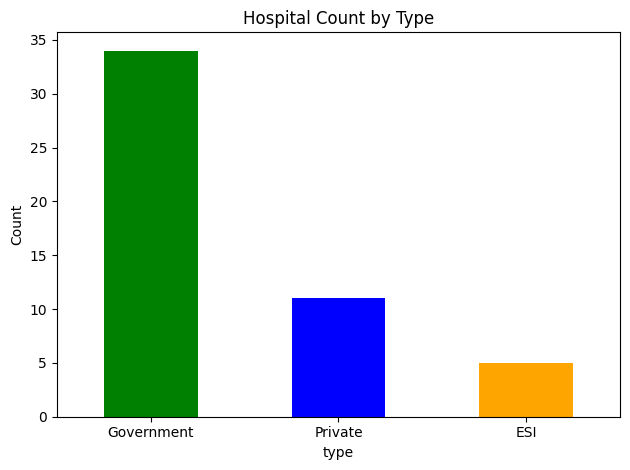

In [16]:
print("=" * 40)
print("HOSPITAL TYPE DISTRIBUTION")
print("=" * 40)
print(df['type'].value_counts())

print("\n" + "=" * 40)
print("AVERAGE BEDS BY HOSPITAL TYPE")
print("=" * 40)
print(df.groupby('type')['beds'].mean().round(0))

print("\n" + "=" * 40)
print("EMERGENCY AVAILABILITY")
print("=" * 40)
print(df['emergency'].value_counts())

print("\n" + "=" * 40)
print("TOP 5 HOSPITALS BY BED COUNT")
print("=" * 40)
print(df[['name','beds','type']].sort_values('beds', ascending=False).head())

# Plot hospital type distribution
df['type'].value_counts().plot(kind='bar', color=['green','blue','orange'],
                                title='Hospital Count by Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Zones assigned ✅

Hospitals per zone:
      hospital_count  avg_beds  total_beds
zone                                      
0                  5     210.0        1050
1                 10     552.0        5520
2                 12     341.0        4090
3                  8     264.0        2110
4                 11     285.0        3137
5                  4     508.0        2031

⚠️ Underserved zones (less than 6 hospitals):
      hospital_count  avg_beds  total_beds
zone                                      
0                  5     210.0        1050
5                  4     508.0        2031


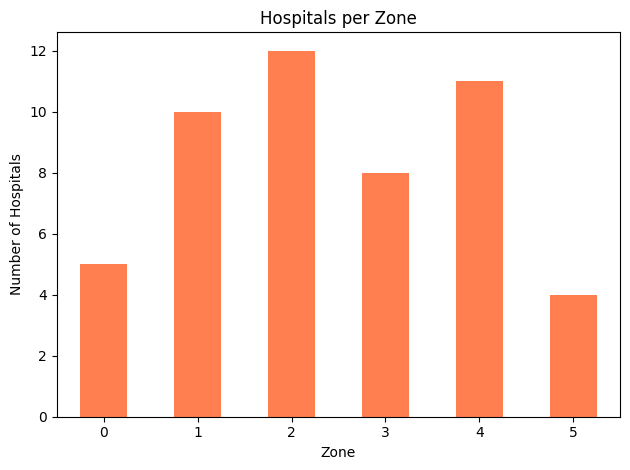

In [17]:


# Use only lat and long for clustering
coords = df[['latitude', 'longitude']]

# We divide Chennai into 6 zones (north, south, east, west, center, outskirts)
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
df['zone'] = kmeans.fit_predict(coords)

print("Zones assigned ✅")
print("\nHospitals per zone:")
zone_counts = df.groupby('zone').agg(
    hospital_count=('name', 'count'),
    avg_beds=('beds', 'mean'),
    total_beds=('beds', 'sum')
).round(0)
print(zone_counts)

print("\n⚠️ Underserved zones (less than 6 hospitals):")
underserved = zone_counts[zone_counts['hospital_count'] < 6]
print(underserved)

# Plot
zone_counts['hospital_count'].plot(kind='bar',
                                    color='coral',
                                    title='Hospitals per Zone')
plt.xlabel('Zone')
plt.ylabel('Number of Hospitals')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [18]:
# Color coding by hospital type
type_colors = {
    'Government': 'green',
    'Private': 'blue',
    'ESI': 'orange'
}

# Zone colors for cluster markers
zone_colors = ['red','purple','darkred','darkblue','cadetblue','darkgreen']
chennai_map = folium.Map(
    location=[13.0827, 80.2707],
    zoom_start=11,
    tiles='https://{s}.tile.openstreetmap.org/{z}/{x}/{y}.png',
    attr='OpenStreetMap'
)

govt_layer = folium.FeatureGroup(name="Government Hospitals")
private_layer = folium.FeatureGroup(name="Private Hospitals")
esi_layer = folium.FeatureGroup(name="ESI Hospitals")
zone_layer = folium.FeatureGroup(name="Zone Centers (Clusters)")


for _, row in df.iterrows():
    color = type_colors.get(row['type'], 'gray')
    popup_text = f"""
    <b>{row['name']}</b><br>
    Type: {row['type']}<br>
    Area: {row['area']}<br>
    Beds: {row['beds']}<br>
    Doctors: {row['doctors']}<br>
    Emergency: {row['emergency']}<br>
    Zone: {row['zone']}
    """
    marker = folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=folium.Popup(popup_text, max_width=200),
        tooltip=row['name'],
        icon=folium.Icon(color=color, icon='plus-sign')
    )
    if row['type'] == 'Government':
        marker.add_to(govt_layer)
    elif row['type'] == 'Private':
        marker.add_to(private_layer)
    else:
        marker.add_to(esi_layer)


centers = kmeans.cluster_centers_
for i, center in enumerate(centers):
    count = len(df[df['zone'] == i])
    status = "⚠️ Underserved" if count < 6 else "✅ Adequate"
    folium.CircleMarker(
        location=[center[0], center[1]],
        radius=30,
        color=zone_colors[i],
        fill=True,
        fill_opacity=0.2,
        popup=f"Zone {i} | Hospitals: {count} | {status}",
        tooltip=f"Zone {i}: {count} hospitals"
    ).add_to(zone_layer)


govt_layer.add_to(chennai_map)
private_layer.add_to(chennai_map)
esi_layer.add_to(chennai_map)
zone_layer.add_to(chennai_map)


legend_html = """
<div style="position: fixed; bottom: 30px; left: 30px; z-index:9999;
     background-color:white; padding:10px; border-radius:8px;
     border: 2px solid grey; font-size:13px;">
<b>Chennai Healthcare Map</b><br>
<i class="fa fa-map-marker" style="color:green"></i> Government Hospital<br>
<i class="fa fa-map-marker" style="color:blue"></i> Private Hospital<br>
<i class="fa fa-map-marker" style="color:orange"></i> ESI Hospital<br>
⚠️ Underserved Zone (< 6 hospitals)
</div>
"""
chennai_map.get_root().html.add_child(folium.Element(legend_html))


folium.LayerControl().add_to(chennai_map)

# Display map in Colab
chennai_map

In [19]:

chennai_map.save("chennai_healthcare_map.html")
print("Map saved ✅")


print("\n" + "=" * 45)
print("   CHENNAI HEALTHCARE ACCESS - SUMMARY")
print("=" * 45)

print(f"\nTotal Hospitals Mapped   : {len(df)}")
print(f"Government Hospitals     : {len(df[df['type']=='Government'])}")
print(f"Private Hospitals        : {len(df[df['type']=='Private'])}")
print(f"ESI Hospitals            : {len(df[df['type']=='ESI'])}")
print(f"Total Beds               : {df['beds'].sum()}")
print(f"Hospitals with Emergency : {len(df[df['emergency']=='Yes'])}")

print("\n--- Zone-wise Analysis ---")
for zone in sorted(df['zone'].unique()):
    zone_df = df[df['zone'] == zone]
    status = "⚠️ UNDERSERVED" if len(zone_df) < 6 else "✅ Adequate"
    print(f"Zone {zone}: {len(zone_df)} hospitals | "
          f"{int(zone_df['beds'].sum())} beds | {status}")

print("\n--- Key Insight ---")
underserved_zones = df.groupby('zone').filter(lambda x: len(x) < 6)
print(f"{len(underserved_zones['zone'].unique())} out of 6 zones are underserved")
print("Recommendation: Prioritize new government hospitals in")
print(underserved_zones.groupby('zone')['area'].first().values)

Map saved ✅

   CHENNAI HEALTHCARE ACCESS - SUMMARY

Total Hospitals Mapped   : 50
Government Hospitals     : 34
Private Hospitals        : 11
ESI Hospitals            : 5
Total Beds               : 17938
Hospitals with Emergency : 22

--- Zone-wise Analysis ---
Zone 0: 5 hospitals | 1050 beds | ⚠️ UNDERSERVED
Zone 1: 10 hospitals | 5520 beds | ✅ Adequate
Zone 2: 12 hospitals | 4090 beds | ✅ Adequate
Zone 3: 8 hospitals | 2110 beds | ✅ Adequate
Zone 4: 11 hospitals | 3137 beds | ✅ Adequate
Zone 5: 4 hospitals | 2031 beds | ⚠️ UNDERSERVED

--- Key Insight ---
2 out of 6 zones are underserved
Recommendation: Prioritize new government hospitals in
['Tambaram' 'Stanley']


In [21]:
from google.colab import files
files.download("chennai_healthcare_map.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>